In [1]:
"""
The Accuracy Paradox: Class Imbalance Case Study
--------------------------------------------------
Generates a synthetic 98/2 imbalanced "medical-imaging-style" dataset,
trains baseline + fixed classifiers, and produces every figure used in
the Medium article.

Run: python3 imbalance_analysis.py
Outputs land in ../figures/
"""

'\nThe Accuracy Paradox: Class Imbalance Case Study\n--------------------------------------------------\nGenerates a synthetic 98/2 imbalanced "medical-imaging-style" dataset,\ntrains baseline + fixed classifiers, and produces every figure used in\nthe Medium article.\n\nRun: python3 imbalance_analysis.py\nOutputs land in ../figures/\n'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    confusion_matrix, precision_recall_curve, average_precision_score,
)
from imblearn.over_sampling import SMOTE

In [3]:
# ----------------------------------------------------------------------
# Style — clean, publication-ready, consistent palette across all figures
# ----------------------------------------------------------------------
import os
try:
    _here = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _here = os.getcwd()  # running inside a notebook — no __file__
FIG_DIR = os.path.join(_here, "..", "figures")
os.makedirs(FIG_DIR, exist_ok=True)
sns.set_theme(style="whitegrid", context="talk")
mpl.rcParams["figure.dpi"] = 150
mpl.rcParams["savefig.dpi"] = 200
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["axes.titleweight"] = "bold"

In [4]:
COLOR_MAJ = "#4C72B0"     # normal / majority class
COLOR_MIN = "#DD5555"     # disease / minority class
COLOR_BASE = "#9099A2"    # baseline / before
COLOR_FIX = "#2E8B57"     # fixed / after

In [5]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [6]:
# ----------------------------------------------------------------------
# 1. Build the dataset — 98% normal / 2% disease, medical-imaging-style
#    feature space (moderate class overlap, realistic difficulty)
# ----------------------------------------------------------------------
X, y = make_classification(
    n_samples=20000,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    n_clusters_per_class=2,
    weights=[0.98, 0.02],
    flip_y=0.01,
    class_sep=0.9,
    random_state=RANDOM_STATE,
)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

In [8]:
print(f"Total samples: {len(y)}")
print(f"Train class counts: {np.bincount(y_train)}  "
      f"({np.bincount(y_train)[1]/len(y_train):.2%} positive)")
print(f"Test class counts:  {np.bincount(y_test)}  "
      f"({np.bincount(y_test)[1]/len(y_test):.2%} positive)")

Total samples: 20000
Train class counts: [14620   380]  (2.53% positive)
Test class counts:  [4874  126]  (2.52% positive)


In [9]:
# ----------------------------------------------------------------------
# 2. The "useless model" one-liner — predict majority class always
# ----------------------------------------------------------------------
dumb_preds = np.zeros_like(y_test)
dumb_acc = accuracy_score(y_test, dumb_preds)
dumb_recall = recall_score(y_test, dumb_preds, zero_division=0)
print(f"\n[Dumb baseline] Always predict 'normal' -> "
      f"Accuracy={dumb_acc:.4f}, Recall(disease)={dumb_recall:.4f}")


[Dumb baseline] Always predict 'normal' -> Accuracy=0.9748, Recall(disease)=0.0000


In [10]:
# ----------------------------------------------------------------------
# 3. Train a real baseline classifier (Random Forest, untouched defaults)
# ----------------------------------------------------------------------
baseline_clf = RandomForestClassifier(
    n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
)
baseline_clf.fit(X_train, y_train)
baseline_pred = baseline_clf.predict(X_test)
baseline_proba = baseline_clf.predict_proba(X_test)[:, 1]

In [11]:
baseline_metrics = {
    "accuracy": accuracy_score(y_test, baseline_pred),
    "precision": precision_score(y_test, baseline_pred, zero_division=0),
    "recall": recall_score(y_test, baseline_pred, zero_division=0),
    "f1": f1_score(y_test, baseline_pred, zero_division=0),
}
print(f"\n[Baseline RF] {baseline_metrics}")


[Baseline RF] {'accuracy': 0.9804, 'precision': 0.9666666666666667, 'recall': 0.23015873015873015, 'f1': 0.3717948717948718}


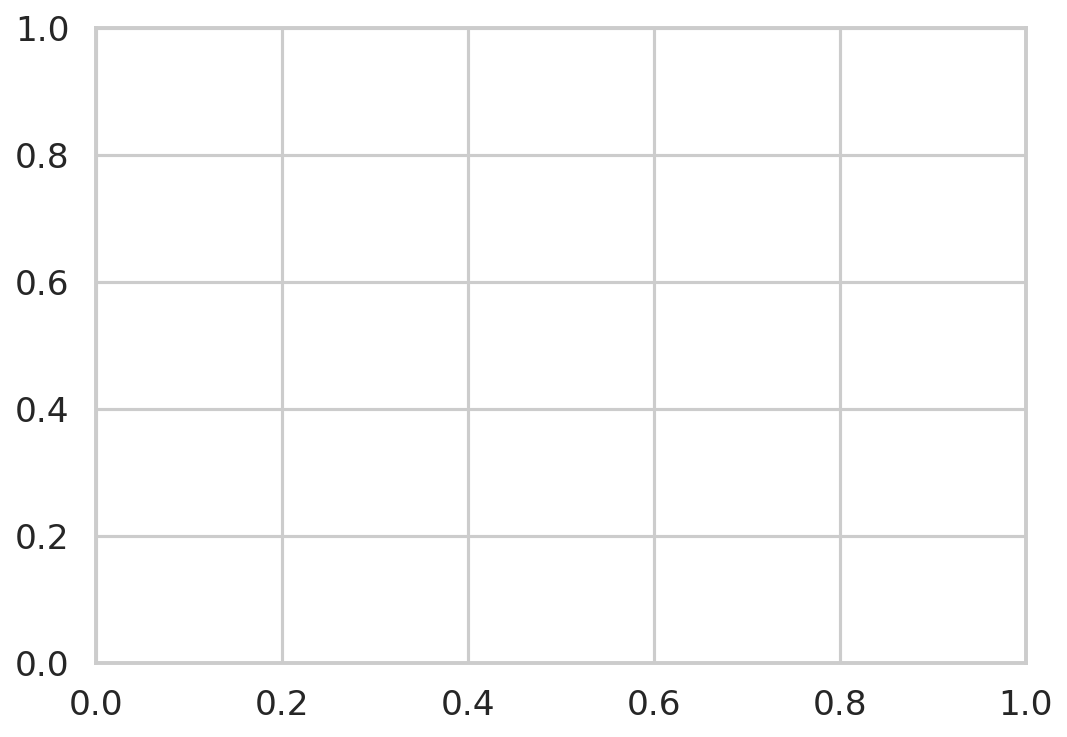

In [12]:
# ----------------------------------------------------------------------
# FIGURE 1 — Accuracy vs. Recall bar comparison (dumb vs baseline model)
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5.5))
labels = ["Predict\n'Normal' Always", "Random Forest\n(default, unweighted)"]
acc_vals = [dumb_acc, baseline_metrics["accuracy"]]
rec_vals = [dumb_recall, baseline_metrics["recall"]]

In [13]:
x = np.arange(len(labels))
width = 0.32
b1 = ax.bar(x - width/2, acc_vals, width, label="Accuracy", color=COLOR_MAJ)
b2 = ax.bar(x + width/2, rec_vals, width, label="Recall (disease class)", color=COLOR_MIN)

In [14]:
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.1%}", (bar.get_x() + bar.get_width()/2, h),
                    ha="center", va="bottom", fontsize=13, fontweight="bold")

In [15]:
ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Score")
ax.set_title("High Accuracy, Blind to the Disease Class")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig1_accuracy_vs_recall.png", bbox_inches="tight")
plt.close()

In [16]:
# ----------------------------------------------------------------------
# FIGURE 2 — Confusion matrix, baseline model (raw counts + %)
# ----------------------------------------------------------------------
def plot_confusion(y_true, y_pred, title, filename, cmap="Blues"):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm_for_color = cm.astype(float) / cm.max()  # drives actual cell shade

    fig, ax = plt.subplots(figsize=(6, 5.2))
    sns.heatmap(
        cm, annot=False, fmt="d", cmap=cmap, cbar=False, ax=ax,
        linewidths=1.5, linecolor="white",
        xticklabels=["Normal", "Disease"], yticklabels=["Normal", "Disease"]
    )
    for i in range(2):
        for j in range(2):
            # text color follows the actual rendered cell darkness, not the
            # row percentage, so small counts on light cells stay readable
            is_dark_cell = cm_norm_for_color[i, j] > 0.55
            ax.text(j + 0.5, i + 0.5, f"{cm[i, j]}\n({cm_pct[i, j]:.1%})",
                     ha="center", va="center", fontsize=14,
                     color="white" if is_dark_cell else "black",
                     fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{filename}", bbox_inches="tight")
    plt.close()
    return cm

In [17]:
cm_baseline = plot_confusion(
    y_test, baseline_pred,
    "Confusion Matrix — Baseline Model\n(Unweighted Random Forest)",
    "fig2_confusion_baseline.png"
)
print(f"\n[Baseline confusion matrix]\n{cm_baseline}")


[Baseline confusion matrix]
[[4873    1]
 [  97   29]]


In [18]:
# ----------------------------------------------------------------------
# FIGURE 3 — Precision-Recall curve, baseline model
# ----------------------------------------------------------------------
prec_base, rec_base, thresh_base = precision_recall_curve(y_test, baseline_proba)
ap_base = average_precision_score(y_test, baseline_proba)

In [19]:
fig, ax = plt.subplots(figsize=(7.5, 6))
ax.plot(rec_base, prec_base, color=COLOR_BASE, linewidth=2.5,
        label=f"Baseline RF (AP={ap_base:.3f})")
prevalence = y_test.mean()
ax.axhline(prevalence, color="gray", linestyle="--", linewidth=1.5,
           label=f"No-skill baseline (prevalence={prevalence:.2%})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Baseline Model")
ax.legend(loc="lower left", frameon=True)
sns.despine()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig3_pr_curve_baseline.png", bbox_inches="tight")
plt.close()

In [20]:
# ----------------------------------------------------------------------
# 4. FIX #1 — class_weight="balanced"
# ----------------------------------------------------------------------
weighted_clf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1
)
weighted_clf.fit(X_train, y_train)
weighted_pred = weighted_clf.predict(X_test)
weighted_proba = weighted_clf.predict_proba(X_test)[:, 1]

In [21]:
weighted_metrics = {
    "accuracy": accuracy_score(y_test, weighted_pred),
    "precision": precision_score(y_test, weighted_pred, zero_division=0),
    "recall": recall_score(y_test, weighted_pred, zero_division=0),
    "f1": f1_score(y_test, weighted_pred, zero_division=0),
}
print(f"\n[Class-weighted RF] {weighted_metrics}")


[Class-weighted RF] {'accuracy': 0.9776, 'precision': 1.0, 'recall': 0.1111111111111111, 'f1': 0.2}


In [22]:
# ----------------------------------------------------------------------
# 5. FIX #2 — SMOTE oversampling (fit on train only, never on test)
# ----------------------------------------------------------------------
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE, train class counts: {np.bincount(y_train_sm)}")


After SMOTE, train class counts: [14620 14620]


In [23]:
smote_clf = RandomForestClassifier(
    n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
)
smote_clf.fit(X_train_sm, y_train_sm)
smote_pred = smote_clf.predict(X_test)
smote_proba = smote_clf.predict_proba(X_test)[:, 1]

In [24]:
smote_metrics = {
    "accuracy": accuracy_score(y_test, smote_pred),
    "precision": precision_score(y_test, smote_pred, zero_division=0),
    "recall": recall_score(y_test, smote_pred, zero_division=0),
    "f1": f1_score(y_test, smote_pred, zero_division=0),
}
print(f"[SMOTE RF] {smote_metrics}")

[SMOTE RF] {'accuracy': 0.9812, 'precision': 0.7285714285714285, 'recall': 0.40476190476190477, 'f1': 0.5204081632653061}


In [25]:
# ----------------------------------------------------------------------
# 6. FIX #3 — Threshold tuning on the ORIGINAL baseline model's scores
#    (find threshold maximizing F1 on validation-style scan)
# ----------------------------------------------------------------------
f1_scores = []
for t in thresh_base:
    preds_t = (baseline_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds_t, zero_division=0))
f1_scores = np.array(f1_scores)
best_idx = f1_scores.argmax()
best_thresh = thresh_base[best_idx]

In [26]:
tuned_pred = (baseline_proba >= best_thresh).astype(int)
tuned_metrics = {
    "accuracy": accuracy_score(y_test, tuned_pred),
    "precision": precision_score(y_test, tuned_pred, zero_division=0),
    "recall": recall_score(y_test, tuned_pred, zero_division=0),
    "f1": f1_score(y_test, tuned_pred, zero_division=0),
    "threshold": best_thresh,
}
print(f"[Threshold-tuned baseline] {tuned_metrics}")

[Threshold-tuned baseline] {'accuracy': 0.9842, 'precision': 0.7473684210526316, 'recall': 0.5634920634920635, 'f1': 0.6425339366515838, 'threshold': np.float64(0.18666666666666668)}


In [27]:
# ----------------------------------------------------------------------
# FIGURE 4 — Precision-Recall curves: baseline vs weighted vs SMOTE
#             (the honest before/after — full curves, not single points)
# ----------------------------------------------------------------------
prec_w, rec_w, _ = precision_recall_curve(y_test, weighted_proba)
ap_w = average_precision_score(y_test, weighted_proba)
prec_s, rec_s, _ = precision_recall_curve(y_test, smote_proba)
ap_s = average_precision_score(y_test, smote_proba)

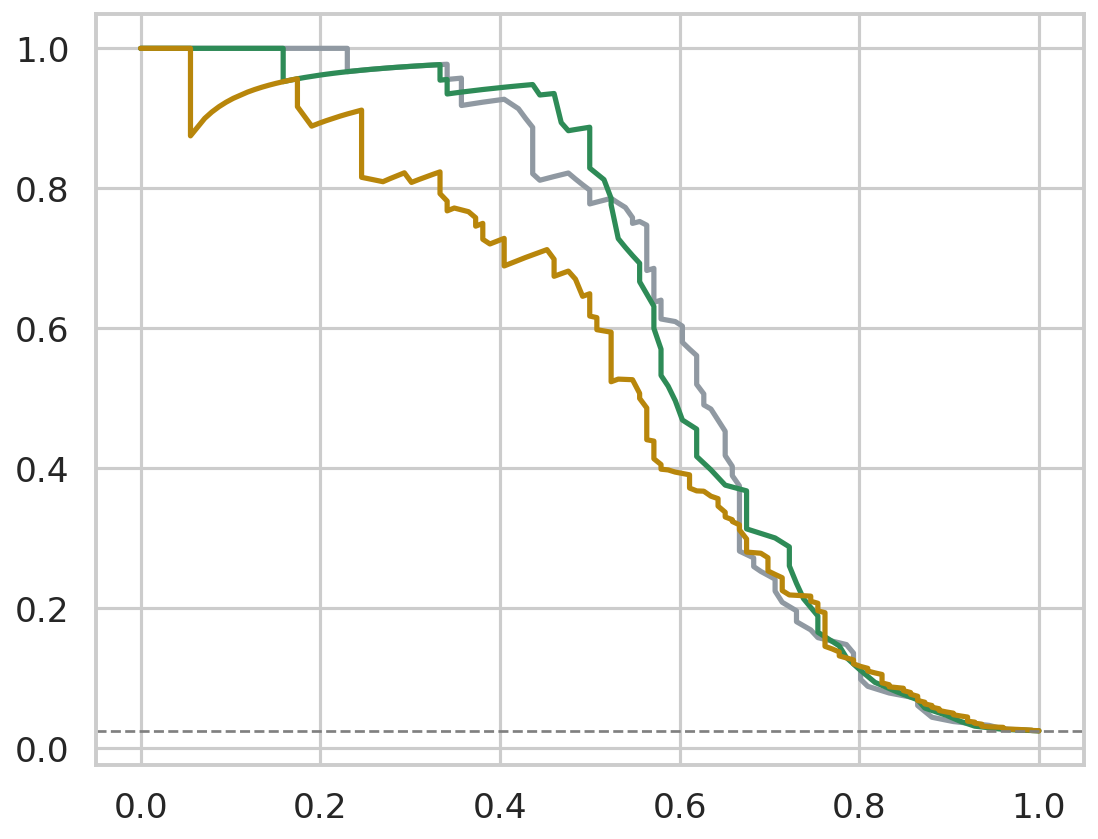

In [28]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))
ax.plot(rec_base, prec_base, color=COLOR_BASE, linewidth=2.5,
        label=f"Baseline (unweighted), AP={ap_base:.3f}")
ax.plot(rec_w, prec_w, color=COLOR_FIX, linewidth=2.5,
        label=f"Class-weighted, AP={ap_w:.3f}")
ax.plot(rec_s, prec_s, color="#B8860B", linewidth=2.5,
        label=f"SMOTE-resampled, AP={ap_s:.3f}")
ax.axhline(prevalence, color="gray", linestyle="--", linewidth=1.3,
           label=f"No-skill (prevalence={prevalence:.2%})")

In [29]:
# Mark the threshold-tuned operating point on the baseline curve
ax.scatter([tuned_metrics["recall"]], [tuned_metrics["precision"]],
           color="black", zorder=5, s=90, marker="X",
           label=f"Tuned threshold ({best_thresh:.2f}) on baseline")

In [30]:
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Fixing Class Imbalance: The Honest Trade-off\n(Precision-Recall, Not a Single Accuracy Number)")
ax.legend(loc="upper right", fontsize=11, frameon=True)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)
sns.despine()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig4_pr_curve_comparison.png", bbox_inches="tight")
plt.close()

In [31]:
# ----------------------------------------------------------------------
# FIGURE 5 — Confusion matrix, class-weighted model (after fix)
# ----------------------------------------------------------------------
cm_weighted = plot_confusion(
    y_test, weighted_pred,
    "Confusion Matrix — Class-Weighted Model\n(class_weight='balanced')",
    "fig5_confusion_weighted.png", cmap="Greens"
)
print(f"\n[Weighted confusion matrix]\n{cm_weighted}")


[Weighted confusion matrix]
[[4874    0]
 [ 112   14]]


In [32]:
# ----------------------------------------------------------------------
# FIGURE 6 — Full metrics comparison table as a grouped bar chart
# ----------------------------------------------------------------------
methods = ["Predict\nMajority", "Baseline\n(unweighted)", "Threshold\nTuned",
           "Class\nWeighted", "SMOTE"]
metrics_all = {
    "Accuracy": [dumb_acc, baseline_metrics["accuracy"], tuned_metrics["accuracy"],
                 weighted_metrics["accuracy"], smote_metrics["accuracy"]],
    "Precision": [0.0, baseline_metrics["precision"], tuned_metrics["precision"],
                  weighted_metrics["precision"], smote_metrics["precision"]],
    "Recall": [dumb_recall, baseline_metrics["recall"], tuned_metrics["recall"],
               weighted_metrics["recall"], smote_metrics["recall"]],
    "F1": [0.0, baseline_metrics["f1"], tuned_metrics["f1"],
           weighted_metrics["f1"], smote_metrics["f1"]],
}

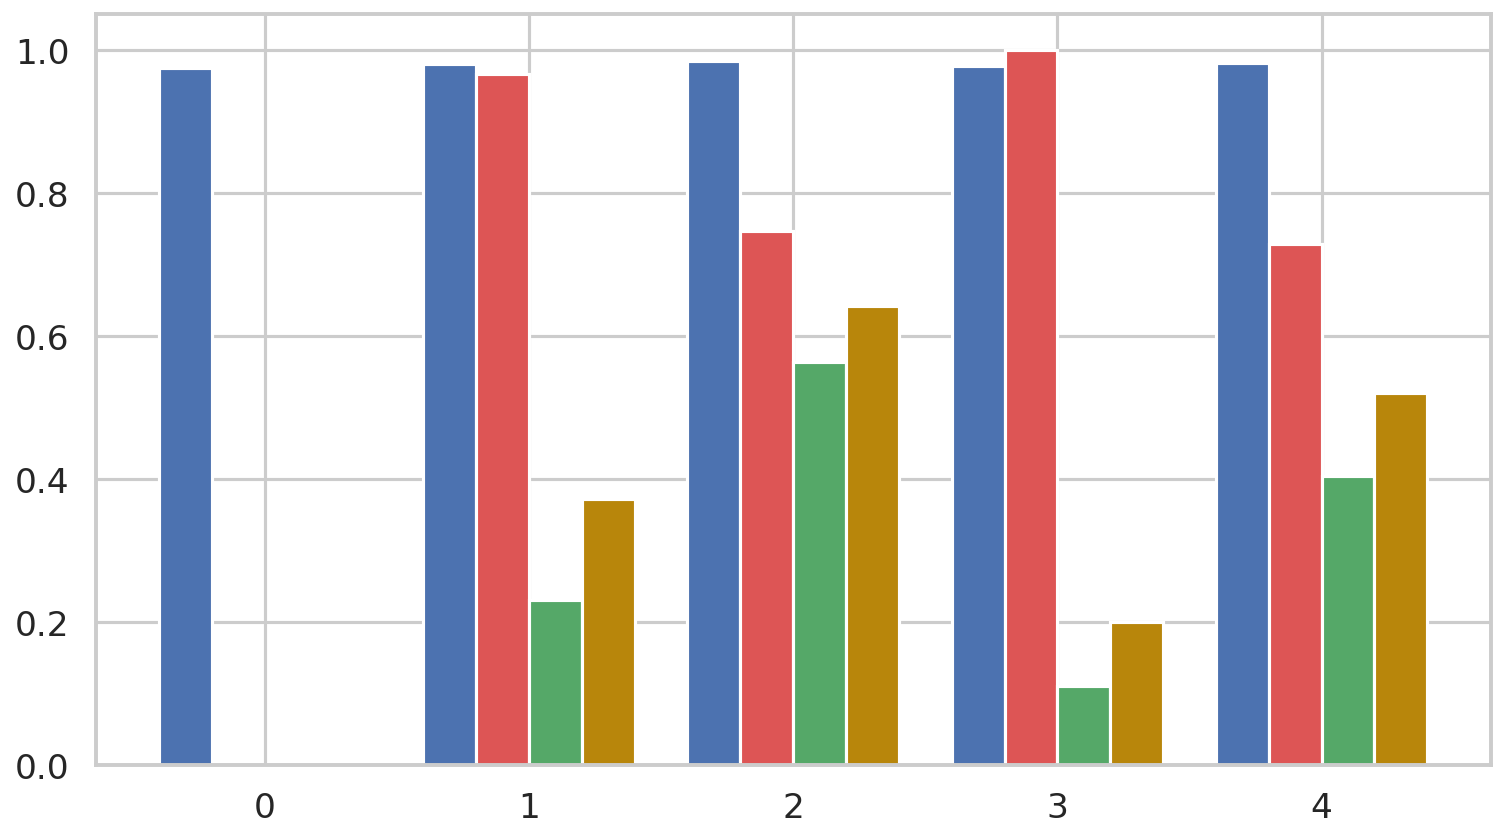

In [33]:
fig, ax = plt.subplots(figsize=(12, 6.5))
x = np.arange(len(methods))
width = 0.2
colors = ["#4C72B0", "#DD5555", "#55A868", "#B8860B"]
for i, (name, vals) in enumerate(metrics_all.items()):
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, vals, width, label=name, color=colors[i])

In [34]:
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("All Five Approaches, Every Metric — Nothing Hidden")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig6_full_comparison.png", bbox_inches="tight")
plt.close()

In [35]:
# ----------------------------------------------------------------------
# Print final summary table for article copy-paste
# ----------------------------------------------------------------------
print("\n" + "="*70)
print(f"{'Method':<22}{'Accuracy':<12}{'Precision':<12}{'Recall':<12}{'F1':<10}")
print("="*70)
rows = [
    ("Predict Majority", dumb_acc, 0.0, dumb_recall, 0.0),
    ("Baseline RF", *baseline_metrics.values()),
    ("Threshold Tuned", tuned_metrics["accuracy"], tuned_metrics["precision"],
     tuned_metrics["recall"], tuned_metrics["f1"]),
    ("Class Weighted", *weighted_metrics.values()),
    ("SMOTE", *smote_metrics.values()),
]
for name, a, p, r, f in rows:
    print(f"{name:<22}{a:<12.4f}{p:<12.4f}{r:<12.4f}{f:<10.4f}")
print("="*70)
print(f"\nBest F1 threshold found: {best_thresh:.4f}")
print("\nAll figures saved to:", FIG_DIR)


Method                Accuracy    Precision   Recall      F1        
Predict Majority      0.9748      0.0000      0.0000      0.0000    
Baseline RF           0.9804      0.9667      0.2302      0.3718    
Threshold Tuned       0.9842      0.7474      0.5635      0.6425    
Class Weighted        0.9776      1.0000      0.1111      0.2000    
SMOTE                 0.9812      0.7286      0.4048      0.5204    

Best F1 threshold found: 0.1867

All figures saved to: /home/claude/imbalance_project/notebook/../figures
